In [89]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [90]:
thyroid = pd.read_csv("Thyroid_ds.csv")

In [91]:
thyroid.head()
thyroid.isnull().sum()

Age                          0
Sex                          0
on_thyroxine                 0
query_on_thyroxine           0
on_antithyroid_medication    0
sick                         0
pregnant                     0
thyroid_surgery              0
I131_treatment               0
query_hypothyroid            0
query_hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH                          0
T3_measured                  0
TT4_measured                 0
T4U_measured                 0
FTI_measured                 0
Outlier_label                0
dtype: int64

In [92]:
thyroid.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [93]:
# FEATURE SELECTION
features = ["Age","Sex","TSH","T3_measured","TT4_measured","T4U_measured","FTI_measured"]
target = ["Outlier_label"]

thyroid["Age"] = (thyroid["Age"] * 100).astype(int)

In [94]:
thyroid.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [95]:
# ENCODE
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
thyroid["Sex"] = le.fit_transform(thyroid["Sex"])

X = thyroid [features]
y = thyroid [target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 45
)

In [96]:
X_train.head()

,Age,Sex,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured
5025,52,0,0.00189,0.0206,0.11118,99.0,0.11207
6882,33,0,0.00004,0.0208,159.00000,101.0,157.00000
113,44,0,28.00000,17.0000,85.00000,101.0,84.00000
6373,64,1,0.00350,18.0000,72.00000,86.0,84.00000
807,74,0,0.00280,0.0200,99.00000,103.0,95.00000


In [110]:
print(thyroid[thyroid["pregnant"] == 1][["Sex", "pregnant"]].head())

     Sex  pregnant
313    0         1
340    0         1
342    0         1
454    0         1
522    0         1


In [111]:
# Decision Tree Model-no Pruning
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [112]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
print("accuracy:",accuracy_score(y_test, y_pred))

accuracy: 0.971820809248555


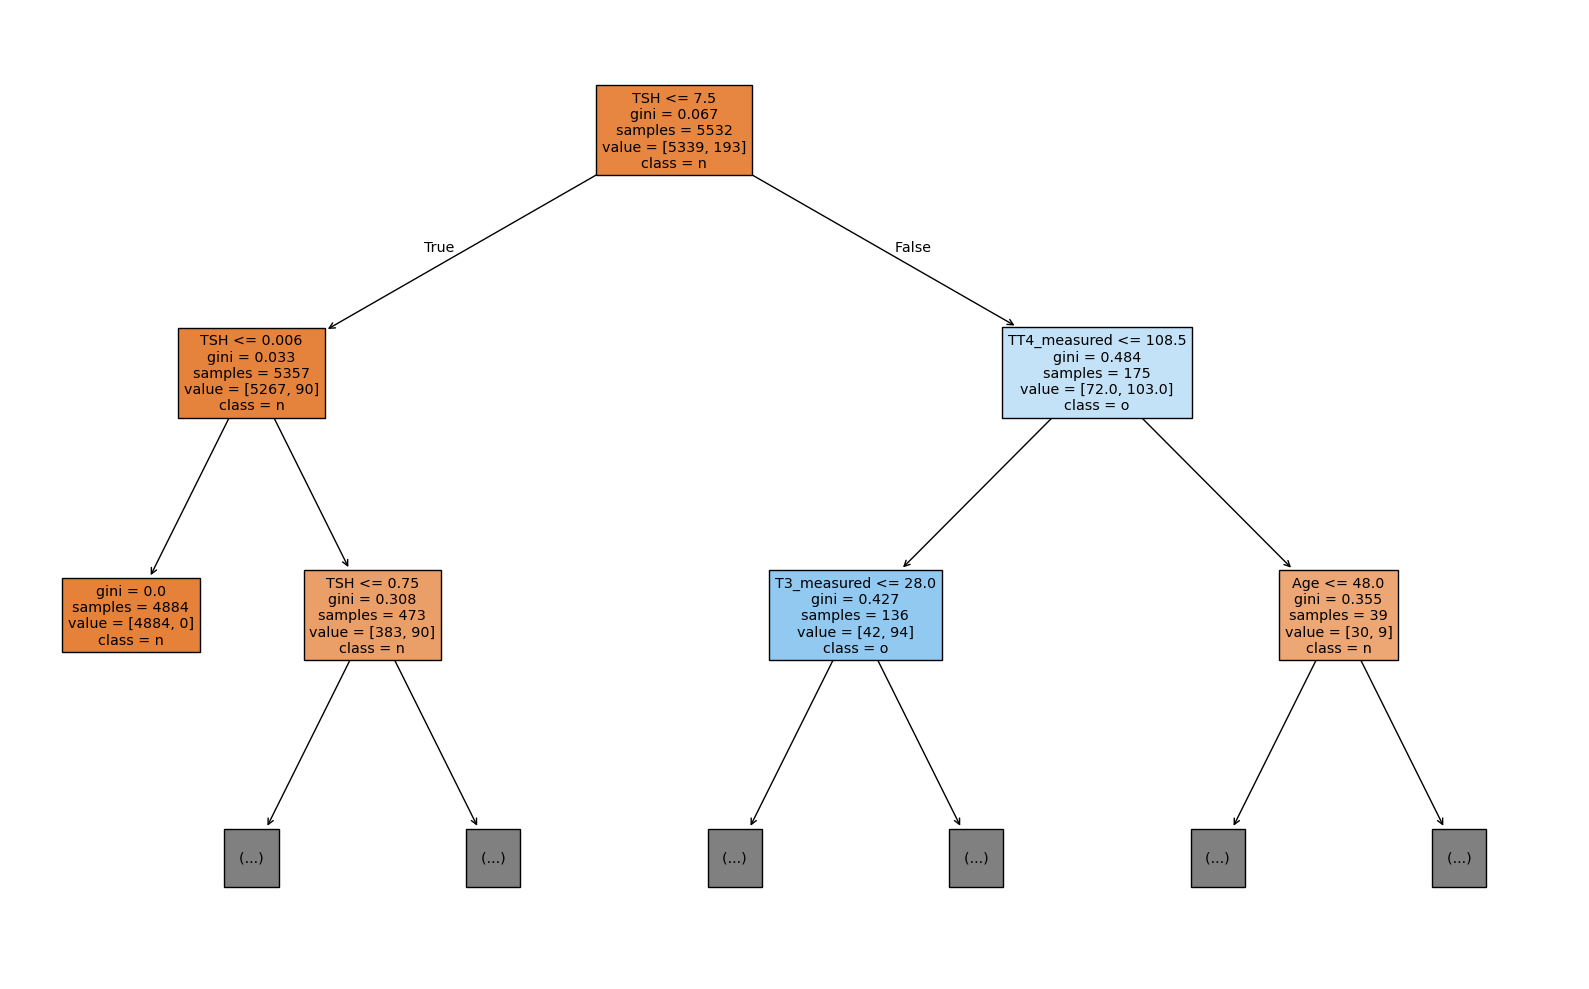

In [113]:
from sklearn.tree import plot_tree
plt.figure(figsize = (16, 10))
plot_tree(
    model,
     feature_names = X.columns,
    class_names = ["n","o"],
    filled = True,
    max_depth = 2
)
plt.tight_layout()
plt.show()

## Decision Tree with Pre-pruning

for depth = 2, accuracy = 0.971820809248555
for depth = 3, accuracy = 0.9747109826589595
for depth = 4, accuracy = 0.9761560693641619
for depth = 5, accuracy = 0.9797687861271677
for depth = 6, accuracy = 0.9761560693641619
for depth = 7, accuracy = 0.9725433526011561
for depth = 8, accuracy = 0.9761560693641619
for depth = 9, accuracy = 0.9761560693641619
for depth = 10, accuracy = 0.9739884393063584


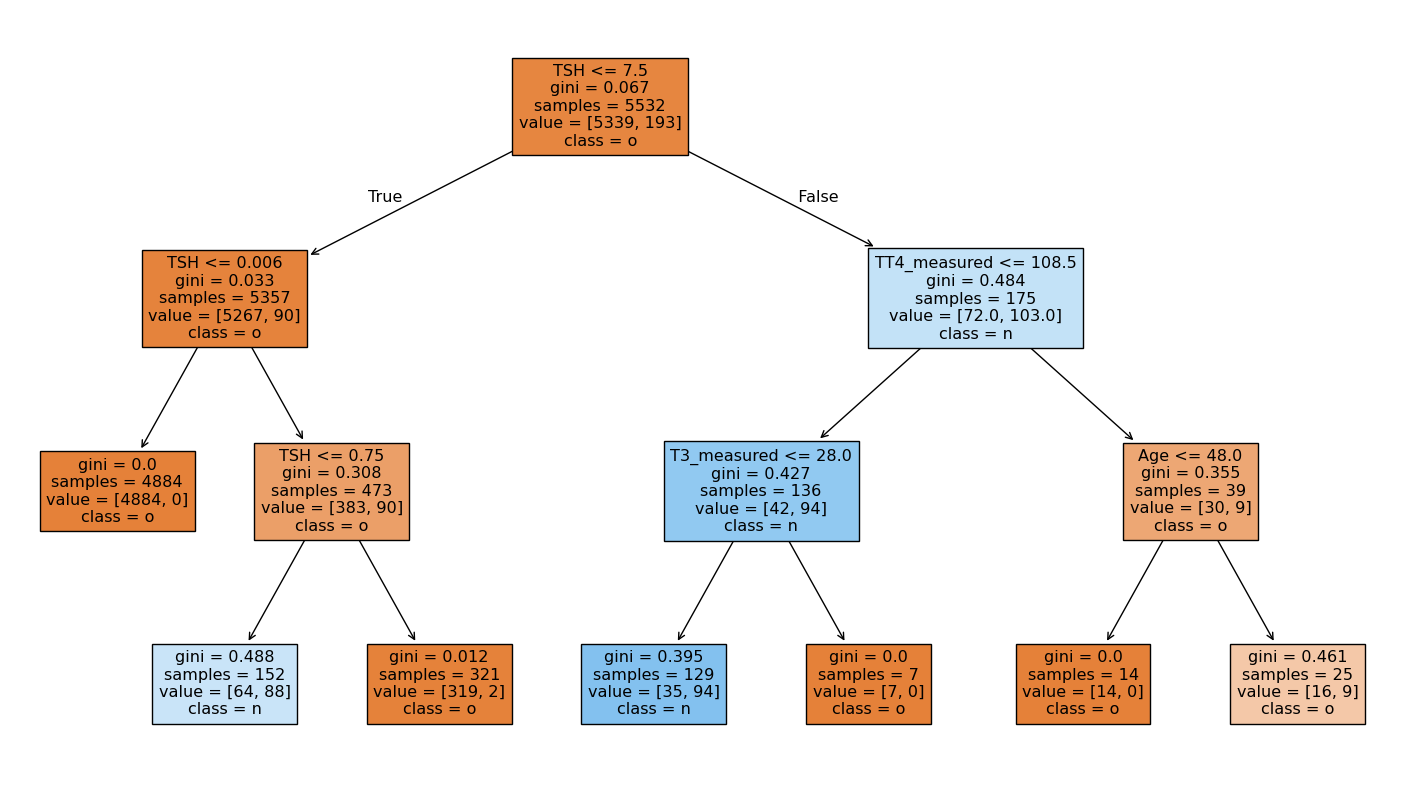

In [114]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]
for depth in max_depths:
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for depth = {depth}, accuracy = {acc}")
    if depth == 3:
        plt.figure(figsize = (18, 10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["o", "n"],
            filled = True,
        )
        

for depth = 2, accuracy = 0.971820809248555
for depth = 3, accuracy = 0.9747109826589595
for depth = 4, accuracy = 0.9761560693641619
for depth = 5, accuracy = 0.9797687861271677
for depth = 6, accuracy = 0.9761560693641619
for depth = 7, accuracy = 0.9739884393063584
for depth = 8, accuracy = 0.9754335260115607
for depth = 9, accuracy = 0.9761560693641619
for depth = 10, accuracy = 0.9732658959537572


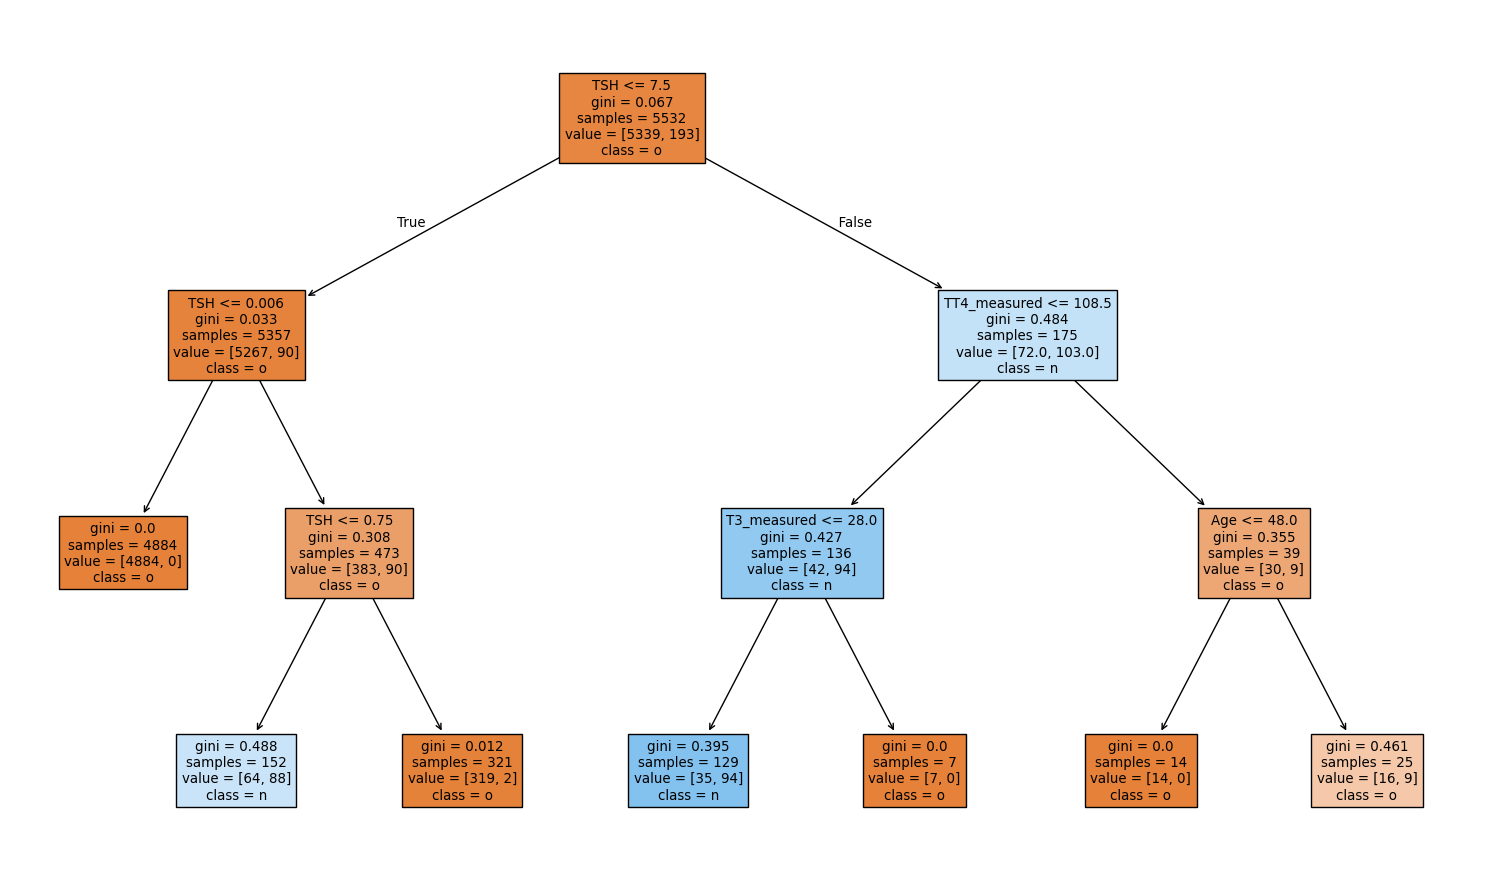

In [115]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]
for depth in max_depths:
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print (f"for depth = {depth}, accuracy = {acc}")
    if depth == 3:
        plt.figure(figsize = (15,9))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["o", "n"],
            filled = True,
        )
        plt.tight_layout()

In [116]:

min_samples_splits = [5, 10, 15, 20, 25, 30]
for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth = 3, min_samples_split = split)
    model.fit(X_train, y_train)
    print(f"for sample split = {split}, accuracy = {acc}")
    if split == 3:
        plt.figure(figsize = (18, 10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["o","n"],
            filled = True
        )
        plt.tight_layout()
        plt.show()

for sample split = 5, accuracy = 0.9732658959537572
for sample split = 10, accuracy = 0.9732658959537572
for sample split = 15, accuracy = 0.9732658959537572
for sample split = 20, accuracy = 0.9732658959537572
for sample split = 25, accuracy = 0.9732658959537572
for sample split = 30, accuracy = 0.9732658959537572


In [117]:
full_tree = DecisionTreeClassifier(random_state = 45)
full_tree.fit(X_train, y_train)

path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)
# train our model for all alphas
tree = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state = 45, ccp_alpha = alpha)
    model.fit(X_train, y_train)
    tree.append(model),
    best_acc = 0,
    best_alpha = 0
    for model.alpha in tree:
        curr_acc = model.score(X_test, y_test)
        if curr_acc == best_acc:
            best_acc = curr_acc
            best_alpha = alpha
    best_acc
plt.tight_layout()
plt.show()

[0.         0.00016068 0.00017354 0.00017368 0.00017381 0.00017656
 0.00018077 0.00018704 0.00023952 0.00024102 0.00024102 0.00025824
 0.00027062 0.00027115 0.00027343 0.00031426 0.00031662 0.00032498
 0.00033894 0.00033894 0.00035058 0.00040957 0.00043801 0.00051918
 0.00052724 0.00053003 0.00058263 0.00064719 0.00064964 0.00116207
 0.00139733 0.00151069 0.00212367 0.00232272 0.0089385  0.02002948]


<Figure size 640x480 with 0 Axes>

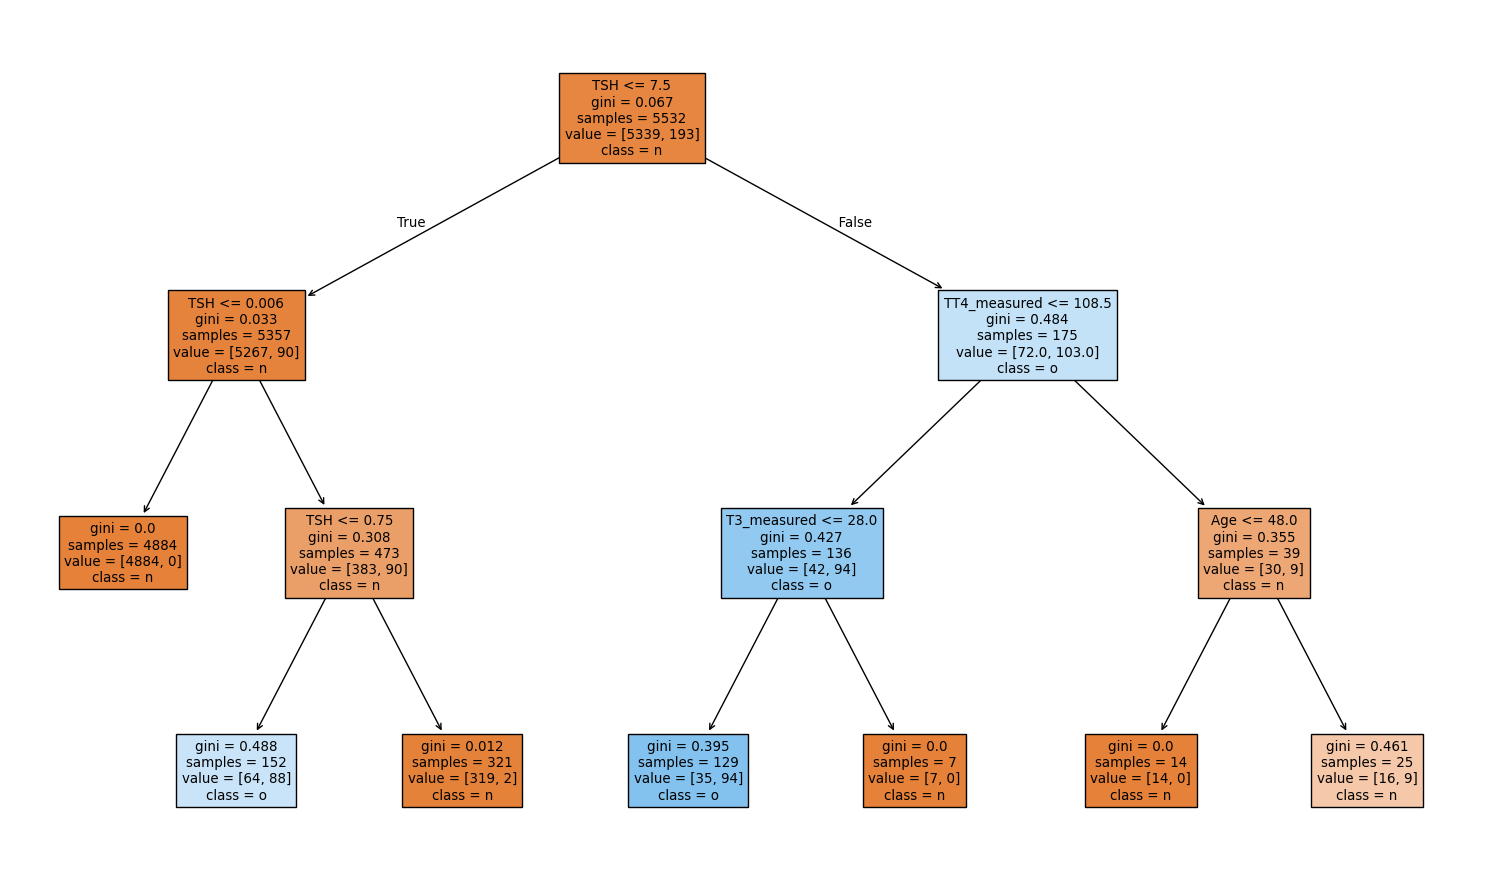

In [118]:
best_model = DecisionTreeClassifier(ccp_alpha = best_alpha, max_depth = 3)
best_model.fit(X_train, y_train)

plt.figure(figsize = (15, 9))
plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["n","o"],
    filled = True
    )
plt.tight_layout()
plt.show()


In [119]:
print(best_model.score(X_test, y_test))

0.9747109826589595
